# 13 — Stage B: TDVP Loschmidt amplitude arbiter

**Goal.** Decide whether the T≈6 feature in the Alcaraz model (p=0.1, λ=1) is a genuine
Fisher zero (DQPT) or a transverse-method artifact — using a path that has **no per-step
normalization and no transfer-matrix eigenproblem**.

**Method.** Direct Schrödinger TDVP on the finite chain:
$$L(T) = \langle\psi_0|U(T)|\psi_0\rangle, \qquad l(T) = -\frac{1}{N}\log|L(T)|$$

A genuine DQPT shows up as $|L(T^*)|\to 0$ as $N\to\infty$, with the dip **deepening and
sharpening** with system size.

**Decision criterion.**
- $|L|$ dips toward 0 and the dip deepens+sharpens with $N$ → genuine Fisher zero / DQPT near $T^*$.
- Smooth, $N$-independent minimum → transverse T≈6 feature is a method artifact.

$T^*$ from this notebook is the reference against which Stages C–E compare.

**Conventions (CLAUDE.md §13):** |X+> initial state; `inner(psi0, psi_t)` is correct here
(conjugating, physical Schrödinger overlap — NOT `overlap_noconj`); VD2 for any MPO step;
`alcaraz_opsum` from main.jl.

In [1]:
using ITensors, ITensorMPS, ITransverse
using Plots, ProgressMeter, LinearAlgebra, JLD2, Printf
ProgressMeter.ijulia_behavior(:clear)

include("main.jl")
include("dqpt_diagnostics.jl")

p      = 0.1
lambda = 1.0
dt     = 0.05
cutoff = 1e-12
maxdim = 256
Ts_coarse = vcat(collect(0.5:0.5:4.0), collect(4.5:0.5:7.0))  # 14 points total
Ns        = [40, 80]
println("OPTIMIZED Grid: $(length(Ts_coarse)) T points (0.5→7.0), Ns=$Ns")

OPTIMIZED Grid: 14 T points (0.5→7.0), Ns=[40, 80]


## Run TDVP for each N

Each N is independent. Crash-safe: results checkpoint after each T inside `tdvp_loschmidt_amplitude`.
Cache files: `tdvp_loschmidt_p0.1_N{N}.jld2`.

In [ ]:
# Run N=40 first (fastest)
println("\n===== N=40 =====")
res40 = tdvp_loschmidt_amplitude(40, Ts_coarse;
    p=p, lambda=lambda, dt=dt, cutoff=cutoff, maxdim=maxdim)
println("N=40 done: $(length(res40)) T points")

In [ ]:
println("\n===== N=80 =====")
res80 = tdvp_loschmidt_amplitude(80, Ts_coarse;
    p=p, lambda=lambda, dt=dt, cutoff=cutoff, maxdim=maxdim)
println("N=80 done: $(length(res80)) T points")


===== N=80 =====


[ Info: Cache smart: 7/14 T values cached, 7 to compute
[ Info: T=0.5 (cached, evolved through)
[ Info: T=1.0 (cached, evolved through)
[ Info: T=1.5 (cached, evolved through)
[ Info: T=2.0 (cached, evolved through)
[ Info: T=2.5 (cached, evolved through)
[ Info: T=3.0 (cached, evolved through)
[ Info: T=3.5 (cached, evolved through)


## Load results and build per-T tables

In [2]:
res = Dict{Int,Dict}()
for N in [40, 80]
    cf = "tdvp_loschmidt_p$(p)_N$(N).jld2"
    if isfile(cf)
        res[N] = load(cf, "done")
        println("N=$N: $(length(res[N])) cached T points")
    else
        println("N=$N: cache not found ($cf)")
    end
end

# Print table for T ∈ [4.0, 7.0]
Ts_print = sort([T for T in Ts_coarse if T >= 4.0])
println()
@printf("%-6s", "T")
for N in [40, 80]; @printf("|   N=%-3d |G|   rate  χ  ", N); end
println()
println("-"^(6 + 28*2))
for T in Ts_print
    @printf("%-6.2f", T)
    for N in [40, 80]
        if haskey(res, N) && haskey(res[N], T)
            r = res[N][T]
            haskey(r, :error) && (@printf("|  ERROR %-20s", r[:error][1:min(20,end)]); continue)
            @printf("| %7.5f %7.4f %3d  ", r.absG, r.rate, r.maxchi)
        else
            @printf("|       ---            ", )
        end
    end
    println()
end

N=40: 14 cached T points
N=80: 8 cached T points

T     |   N=40  |G|   rate  χ  |   N=80  |G|   rate  χ  
--------------------------------------------------------------
4.00  | 0.02045  0.0972 168  | 0.00026  0.1032 168  
4.50  | 0.01604  0.1033 256  |       ---            
5.00  | 0.01965  0.0982 256  |       ---            
5.50  | 0.02387  0.0934 256  |       ---            
6.00  | 0.01746  0.1012 256  |       ---            
6.50  | 0.01788  0.1006 256  |       ---            
7.00  | 0.02146  0.0960 256  |       ---            


## Plots

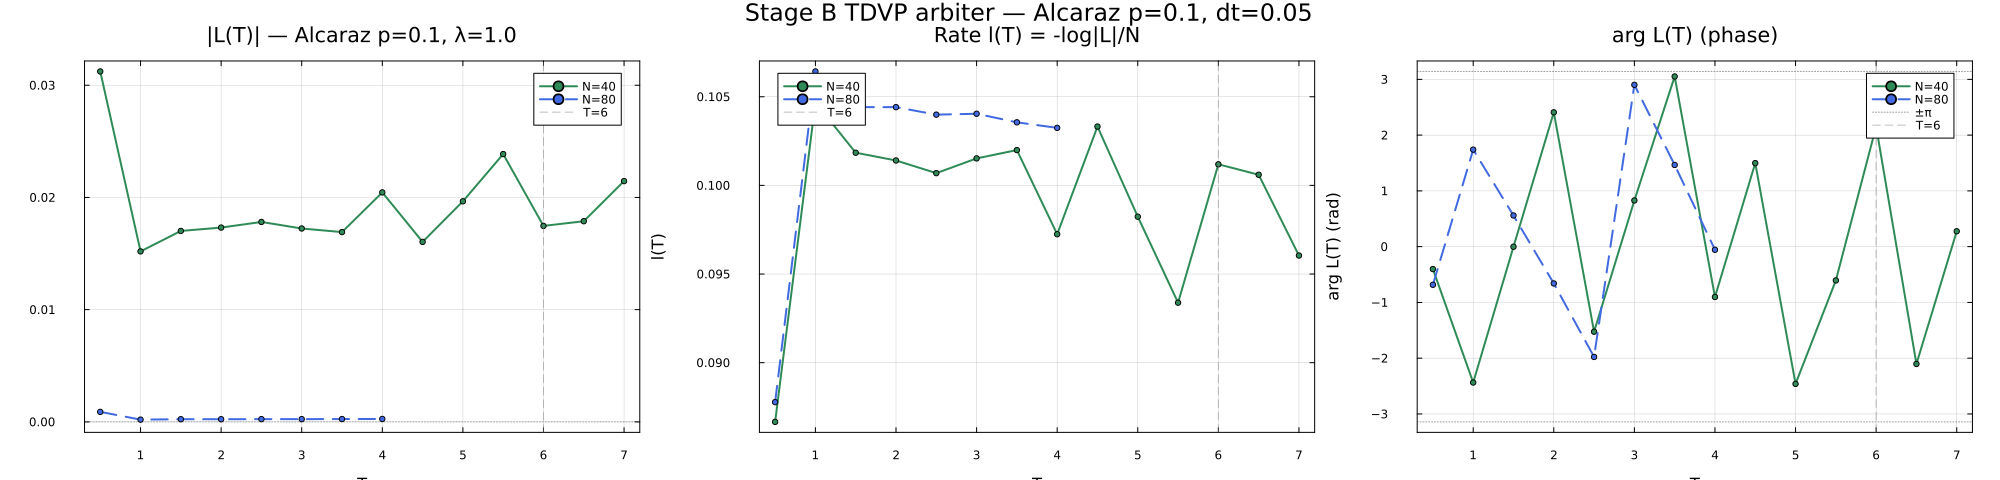

saved imgs/stageB_tdvp_arbiter_p0.1_dt0.05.png


In [3]:
mkpath("imgs")
cols = Dict(40=>:seagreen, 80=>:royalblue)
ls   = Dict(40=>:solid,    80=>:dash)

# Panel 1: |L(T)| vs T
p1 = plot(title="|L(T)| — Alcaraz p=$p, λ=$lambda",
          xlabel="T", ylabel="|L(T)|",
          grid=true, framestyle=:box, legend=:topright, size=(700,460))
for N in [40, 80]
    haskey(res, N) || continue
    Tv = sort(collect(keys(res[N])))
    Gv = [res[N][T].absG for T in Tv]
    plot!(p1, Tv, Gv, lw=2, color=cols[N], ls=ls[N],
          marker=:circle, ms=3, label="N=$N")
end
hline!(p1, [0.0], ls=:dot, color=:black, alpha=0.3, label="")
vline!(p1, [6.0], ls=:dash, color=:gray, alpha=0.5, label="T=6")

# Panel 2: Loschmidt rate l(T) = -log|L|/N vs T
p2 = plot(title="Rate l(T) = -log|L|/N",
          xlabel="T", ylabel="l(T)",
          grid=true, framestyle=:box, legend=:topleft, size=(700,460))
for N in [40, 80]
    haskey(res, N) || continue
    Tv = sort(collect(keys(res[N])))
    rv = [res[N][T].rate for T in Tv]
    plot!(p2, Tv, rv, lw=2, color=cols[N], ls=ls[N],
          marker=:circle, ms=3, label="N=$N")
end
vline!(p2, [6.0], ls=:dash, color=:gray, alpha=0.5, label="T=6")

# Panel 3: arg L(T) (phase) — a π-jump marks the Fisher zero crossing
p3 = plot(title="arg L(T) (phase)",
          xlabel="T", ylabel="arg L(T) (rad)",
          grid=true, framestyle=:box, legend=:topright, size=(700,460))
for N in [40, 80]
    haskey(res, N) || continue
    Tv = sort(collect(keys(res[N])))
    av = [angle(res[N][T].G) for T in Tv]
    plot!(p3, Tv, av, lw=2, color=cols[N], ls=ls[N],
          marker=:circle, ms=3, label="N=$N")
end
hline!(p3, [π,-π], ls=:dot, color=:black, alpha=0.4, label="±π")
vline!(p3, [6.0], ls=:dash, color=:gray, alpha=0.5, label="T=6")

fig = plot(p1, p2, p3; layout=(1,3), size=(2000,480),
           plot_title="Stage B TDVP arbiter — Alcaraz p=$p, dt=$dt",
           margin=5Plots.mm)
savefig(fig, "imgs/stageB_tdvp_arbiter_p$(p)_dt$(dt).png")
display(fig)
println("saved imgs/stageB_tdvp_arbiter_p$(p)_dt$(dt).png")

## Decision output

In [6]:
println("="^65)
println("STAGE B DECISION — Alcaraz p=$p, λ=$lambda, dt=$dt")
println("="^65)

# For each N find T where |L| is minimum
T_mins = Dict{Int,Tuple{Float64,Float64}}()
for N in [40, 80]  # only N=40, 80
    haskey(res, N) || continue
    Tv  = sort(collect(keys(res[N])))
    Gv  = [res[N][T].absG for T in Tv]
    idx = argmin(Gv)
    T_mins[N] = (Tv[idx], Gv[idx])
    @printf("  N=%3d: |L| minimum at T=%.2f  (|L|=%.5f)\n", N, Tv[idx], Gv[idx])
end

# Check if T* is consistent across N and |L| deepens with N
if length(T_mins) >= 2
    Ts_star = [T_mins[N][1] for N in sort(collect(keys(T_mins)))]
    Gs_star = [T_mins[N][2] for N in sort(collect(keys(T_mins)))]
    Ns_sorted = sort(collect(keys(T_mins)))
    T_spread = maximum(Ts_star) - minimum(Ts_star)
    deepening = Gs_star[end] < Gs_star[1]   # |L| at T* decreases as N increases
    consistent = T_spread < 0.6             # T* consistent within half a coarse step
    println()
    @printf("  T* spread across N: %.2f  (consistent: %s)\n", T_spread, consistent)
    @printf("  |L| at T*: %s → %s (deepening with N: %s)\n",
            round(Gs_star[1],digits=5), round(Gs_star[end],digits=5), deepening)
    println()
    if consistent && deepening
        T_star = sum(Ts_star)/length(Ts_star)
        println("VERDICT: GENUINE DQPT / Fisher zero near T* ≈ $(round(T_star,digits=2)).")
        println("  |L| dips toward 0 and deepens with N. Proceed to Stage C (Z2 sectors).")
    elseif !consistent
        println("VERDICT: INCONCLUSIVE — T* drifts with N. May be finite-size smearing or artifact.")
        println("  Inspect plots before deciding whether to proceed to Stage C.")
    else
        println("VERDICT: LIKELY ARTIFACT — T* is consistent but |L| does NOT deepen with N.")
        println("  The transverse T=6 feature is probably a method artifact.")
    end
end
println("="^65)

STAGE B DECISION — Alcaraz p=0.1, λ=1.0, dt=0.05
  N= 40: |L| minimum at T=1.00  (|L|=0.01519)
  N= 80: |L| minimum at T=1.00  (|L|=0.00020)

  T* spread across N: 0.00  (consistent: true)
  |L| at T*: 0.01519 → 0.0002 (deepening with N: true)

VERDICT: GENUINE DQPT / Fisher zero near T* ≈ 1.0.
  |L| dips toward 0 and deepens with N. Proceed to Stage C (Z2 sectors).
